# Check LSST colors of template SEDs

Made by Shenming Fu. 

Eric Charles pointed me to the h5 file (which could be made by Sam Schmidt).

First run `https://github.com/LSSTDESC/pz_data_challenge.git`

The data is in the `nb` folder.

In [10]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [11]:
FILENAME = "CWWSB_LSST_Roman_colors_YJH.hdf5"

BAND_LIST = [
'u',
'g',
'r',
'i',
'z',
'y',
]

In [12]:
def get_redshift():
    with h5py.File(FILENAME, "r") as hf:
        redshift = hf["redshift"][:]
    return redshift

In [13]:
def get_color(SED_name, band1_name, band2_name):
    
    band1_index = BAND_LIST.index(band1_name)
    band2_index = BAND_LIST.index(band2_name)

    color_name = f"{band1_name}{band2_name}"
    
    with h5py.File(FILENAME, "r") as hf:
        if (band1_index+1)==band2_index:
            color = hf[f"{SED_name}_{color_name}"][:]
        else:
            color = np.zeros_like(hf["redshift"][:])
            
            band1_name_tmp = band1_name
            while 1:
                band2_name_tmp = BAND_LIST[BAND_LIST.index(band1_name_tmp)+1]
                color_name_tmp = f"{band1_name_tmp}{band2_name_tmp}"
                color_tmp = hf[f"{SED_name}_{color_name_tmp}"][:]
                color += color_tmp
                band1_name_tmp = band2_name_tmp
                if band2_name_tmp == band2_name:
                    break
            
    return color

In [14]:
def make_cc_plot(SED_name, band1_name, band2_name, band3_name, band4_name):

    redshift = get_redshift()
    #print(f"max redshift: {np.max(redshift)}")
    sel = redshift < 1.5
    
    color1 = get_color(SED_name, band1_name, band2_name)
    color2 = get_color(SED_name, band3_name, band4_name)

    color1_name = f"{band1_name}-{band2_name}"
    color2_name = f"{band3_name}-{band4_name}"
    
    fig, ax = plt.subplots(1,1,figsize=(3.5,3),layout='constrained')
    im = ax.scatter(color1[sel], color2[sel], c=redshift[sel], cmap='jet')
    plt.colorbar(im, ax=ax)
    ax.set_xlabel(color1_name)
    ax.set_ylabel(color2_name)
    ax.grid(ls=':')
    ax.set_title(SED_name)
    plt.savefig(f"{SED_name}_{color1_name}_{color2_name}.png")
    
    return 0

0

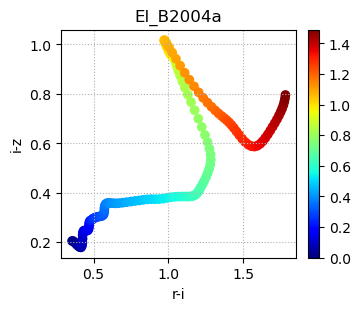

In [15]:
SED_name = "El_B2004a"
make_cc_plot(SED_name, 'r', 'i', 'i', 'z')

0

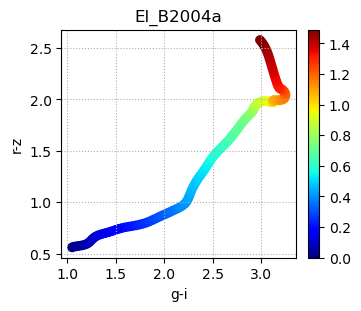

In [16]:
SED_name = "El_B2004a"
make_cc_plot(SED_name, 'g', 'i', 'r', 'z')

0

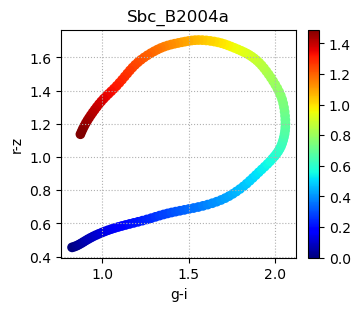

In [17]:
SED_name = "Sbc_B2004a"
make_cc_plot(SED_name, 'g', 'i', 'r', 'z')